In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import psutil
import time

spark = SparkSession.builder \
    .appName("EV_Charging_Scaling") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# 2. Log system info
print("="*50)
print("SYSTEM INFO:")
print(f"RAM total: {psutil.virtual_memory().total / 1024**3:.1f} GB")
print(f"RAM available: {psutil.virtual_memory().available / 1024**3:.1f} GB")
print(f"CPU cores: {psutil.cpu_count()}")
print("="*50)


SYSTEM INFO:
RAM total: 7.6 GB
RAM available: 1.6 GB
CPU cores: 4


In [ ]:

# ============================================================================
# GENERATE LARGER DATASET (2GB) FOR SCALING DEMO
# ============================================================================
print("Generating 2GB synthetic EV charging data...")

# Đọc dữ liệu gốc
df_original = spark.read.parquet("hdfs://localhost:9000/ev-project/data/silver/ev_sessions_preprocessed")

# Nhân bản dữ liệu để đạt 2GB
scale_factor = 70  # 31k rows * 70 ≈ 2.1M rows ≈ 2GB
df_large = df_original

for i in range(7):  # Mỗi lần nhân đôi
    df_large = df_large.union(df_original)
    print(f"  Iteration {i+1}: {df_large.count():,} rows")

# Thêm noise nhẹ để tránh duplicate hoàn hảo
from pyspark.sql.functions import rand
df_large = df_large.withColumn("noise", rand(seed=42) * 0.01)
df_large = df_large.withColumn("kWhDelivered", col("kWhDelivered") + col("noise"))
df_large = df_large.drop("noise")

# Lưu large dataset
large_path = "hdfs://localhost:9000/ev-project/data/silver/ev_sessions_large_2gb"
df_large.write.mode("overwrite").parquet(large_path)
print(f"✓ Generated {df_large.count():,} rows (~2GB)")

In [3]:
# ============================================================================
# BENCHMARK SCALING PERFORMANCE
# ============================================================================
print("\n" + "="*80)
print("BENCHMARK: SCALING PERFORMANCE")
print("="*80)

import time

def benchmark_training(df, data_size, num_partitions=8):
    """Benchmark training time on different data sizes"""
    
    # Repartition
    df = df.repartition(num_partitions)
    
    # Prepare features
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    df_features = assembler.transform(df)
    
    # Train GBT
    gbt = GBTRegressor(featuresCol="features", labelCol="kWhDelivered", 
                       maxIter=20, maxDepth=5, seed=42)
    
    start_time = time.time()
    model = gbt.fit(df_features)
    train_time = time.time() - start_time
    
    # Predict
    predictions = model.transform(df_features)
    
    # Evaluate
    rmse = evaluator_rmse.evaluate(predictions)
    
    return {
        "rows": df.count(),
        "partitions": num_partitions,
        "train_time": train_time,
        "rmse": rmse
    }

# Test với different data sizes
sizes = [0.1, 0.25, 0.5, 0.75, 1.0]  # Fraction of large dataset
results = []

for frac in sizes:
    df_sample = df_large.sample(fraction=frac, seed=42)
    result = benchmark_training(df_sample, f"{frac*100}%")
    results.append(result)
    print(f"\nData size: {result['rows']:,} rows")
    print(f"  Train time: {result['train_time']:.2f} seconds")
    print(f"  RMSE: {result['rmse']:.4f}")

# Plot scaling
import matplotlib.pyplot as plt

rows = [r['rows'] for r in results]
times = [r['train_time'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(rows, times, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Rows')
plt.ylabel('Training Time (seconds)')
plt.title('Spark Scaling: Training Time vs Data Size')
plt.grid(True, alpha=0.3)
plt.savefig('scaling_benchmark.png')
print("\n✓ Scaling plot saved to scaling_benchmark.png")


BENCHMARK: SCALING PERFORMANCE


NameError: name 'VectorAssembler' is not defined

In [4]:
# ============================================================================
# BENCHMARK SCALING PERFORMANCE (FIXED)
# ============================================================================

print("\n" + "="*80)
print("BENCHMARK: SCALING PERFORMANCE")
print("="*80)

import time
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Định nghĩa feature_cols (nếu chưa có)
feature_cols = [
    "hour", "day_of_week", "month", "season",
    "duration", "charging_duration", "charging_duration_log",
    "hour_sin", "hour_cos", "day_of_year", "week_of_year",
    "is_holiday",
    "lag_1_log", "lag_2_log", "lag_3_log",
    "rolling_mean_3_log", "rolling_mean_5_log"
]

# Định nghĩa evaluator
evaluator_rmse = RegressionEvaluator(labelCol="kWhDelivered", predictionCol="prediction", metricName="rmse")

def benchmark_training(df, data_size, num_partitions=8):
    """Benchmark training time on different data sizes"""
    
    print(f"  Benchmarking {data_size}...")
    
    # Repartition
    df = df.repartition(num_partitions)
    
    # Prepare features
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    df_features = assembler.transform(df)
    
    # Train GBT (light config for benchmarking)
    gbt = GBTRegressor(
        featuresCol="features", 
        labelCol="kWhDelivered", 
        maxIter=20,      # Reduced for faster benchmarking
        maxDepth=5, 
        seed=42
    )
    
    start_time = time.time()
    model = gbt.fit(df_features)
    train_time = time.time() - start_time
    
    # Predict
    predictions = model.transform(df_features)
    
    # Evaluate
    rmse = evaluator_rmse.evaluate(predictions)
    
    return {
        "rows": df.count(),
        "partitions": num_partitions,
        "train_time": train_time,
        "rmse": rmse
    }

# ============================================================================
# TẠO DỮ LIỆU LỚN HƠN (nếu chưa có)
# ============================================================================
print("\n[1/3] Creating large dataset for scaling test...")

# Đọc dữ liệu gốc từ silver
try:
    df_original = spark.read.parquet("hdfs://localhost:9000/ev-project/data/silver/ev_sessions_preprocessed")
    print(f"✓ Loaded original data: {df_original.count():,} rows")
except:
    print("❌ Cannot load from silver, using existing df_silver")
    df_original = df_silver

# Tạo larger dataset bằng cách nhân bản
df_large = df_original
original_count = df_original.count()

# Nhân bản để đạt ~200k rows (đủ để test scaling, không cần 2GB)
target_rows = 200000
replication_factor = target_rows // original_count

for i in range(replication_factor - 1):
    df_large = df_large.union(df_original)
    print(f"  Replicated {i+2} times: {df_large.count():,} rows")

print(f"✓ Large dataset ready: {df_large.count():,} rows")

# ============================================================================
# TEST SCALING WITH DIFFERENT DATA SIZES
# ============================================================================
print("\n[2/3] Testing scaling performance...")

# Test với different data sizes
sizes = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]  # Fraction of large dataset
results = []

for frac in sizes:
    print(f"\n  Testing with {frac*100:.0f}% of data...")
    df_sample = df_large.sample(fraction=frac, seed=42)
    
    # Cache để tăng tốc
    df_sample.cache()
    
    result = benchmark_training(df_sample, f"{frac*100:.0f}%")
    results.append(result)
    
    print(f"    ✓ Rows: {result['rows']:,}")
    print(f"    ✓ Train time: {result['train_time']:.2f} seconds")
    print(f"    ✓ RMSE: {result['rmse']:.4f}")
    
    # Uncache
    df_sample.unpersist()

# ============================================================================
# PLOT SCALING RESULTS
# ============================================================================
print("\n[3/3] Plotting scaling results...")

import matplotlib.pyplot as plt
import numpy as np

rows = [r['rows'] for r in results]
times = [r['train_time'] for r in results]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training time vs data size
ax1.plot(rows, times, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Rows', fontsize=12)
ax1.set_ylabel('Training Time (seconds)', fontsize=12)
ax1.set_title('Spark Scaling: Training Time vs Data Size', fontsize=14)
ax1.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(rows, times, 1)
p = np.poly1d(z)
ax1.plot(rows, p(rows), "r--", alpha=0.5, label=f'Trend: {z[0]:.2e}x + {z[1]:.2f}')
ax1.legend()

# Plot 2: RMSE vs data size
ax2.plot(rows, [r['rmse'] for r in results], 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Rows', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Model Accuracy vs Data Size', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=results[-1]['rmse'], color='r', linestyle='--', alpha=0.5, label='Final RMSE')

plt.tight_layout()
plt.savefig('scaling_benchmark.png', dpi=150)
plt.show()

print("\n✓ Scaling plot saved to 'scaling_benchmark.png'")

# ============================================================================
# PRINT SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("SCALING BENCHMARK SUMMARY")
print("="*80)

print(f"\n{'Data Size':<15} {'Rows':<15} {'Train Time (s)':<15} {'RMSE':<10}")
print("-" * 60)

for r in results:
    size_pct = f"{r['rows']/original_count*100:.0f}%"
    print(f"{size_pct:<15} {r['rows']:<15,} {r['train_time']:<15.2f} {r['rmse']:<10.4f}")

# Calculate scaling efficiency
if len(results) >= 2:
    first_time = results[0]['train_time']
    last_time = results[-1]['train_time']
    first_rows = results[0]['rows']
    last_rows = results[-1]['rows']
    
    expected_time = first_time * (last_rows / first_rows)
    efficiency = (expected_time / last_time) * 100
    
    print(f"\n📊 Scaling Analysis:")
    print(f"  Smallest: {first_rows:,} rows → {first_time:.2f}s")
    print(f"  Largest:  {last_rows:,} rows → {last_time:.2f}s")
    print(f"  Expected time (linear): {expected_time:.2f}s")
    print(f"  Scaling efficiency: {efficiency:.1f}%")
    
    if efficiency > 70:
        print("  ✅ Near-linear scaling - Good for big data!")
    else:
        print("  ⚠️ Sub-linear scaling - Consider optimization")

print("\n" + "="*80)
print("✅ SCALING BENCHMARK COMPLETE!")
print("="*80)


BENCHMARK: SCALING PERFORMANCE

[1/3] Creating large dataset for scaling test...
✓ Loaded original data: 31,393 rows


  Replicated 2 times: 62,786 rows


  Replicated 3 times: 94,179 rows


  Replicated 4 times: 125,572 rows


  Replicated 5 times: 156,965 rows


...

26/04/11 15:29:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/11 15:29:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

    ✓ Rows: 9,455
    ✓ Train time: 33.96 seconds
    ✓ RMSE: 4.7375

  Testing with 10% of data...
  Benchmarking 10%...


    ✓ Rows: 18,941
    ✓ Train time: 30.49 seconds
    ✓ RMSE: 4.8756

  Testing with 20% of data...
  Benchmarking 20%...


26/04/11 15:30:00 ERROR Executor: Exception in task 0.0 in stage 697.0 (TID 3935)
org.apache.spark.SparkException: [FAILED_EXECUTE_UDF] Failed to execute user defined function (`VectorAssembler$$Lambda/0x000072dc0497b800`: (struct<hour_double_VectorAssembler_af03e4c29c5a:double,day_of_week_double_VectorAssembler_af03e4c29c5a:double,month_double_VectorAssembler_af03e4c29c5a:double,season_double_VectorAssembler_af03e4c29c5a:double,duration:double,charging_duration:double,charging_duration_log:double,hour_sin:double,hour_cos:double,day_of_year_double_VectorAssembler_af03e4c29c5a:double,week_of_year_double_VectorAssembler_af03e4c29c5a:double,is_holiday_double_VectorAssembler_af03e4c29c5a:double,lag_1_log:double,lag_2_log:double,lag_3_log:double,rolling_mean_3_log:double,rolling_mean_5_log:double>) => struct<type:tinyint,size:int,indices:array<int>,values:array<double>>).
	at org.apache.spark.sql.errors.QueryExecutionErrors$.failedExecuteUserDefinedFunctionError(QueryExecutionErrors.scala:1

Py4JJavaError: An error occurred while calling o445.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 6 in stage 697.0 failed 1 times, most recent failure: Lost task 6.0 in stage 697.0 (TID 3941) (192.168.40.130 executor driver): org.apache.spark.SparkException: [FAILED_EXECUTE_UDF] Failed to execute user defined function (`VectorAssembler$$Lambda/0x000072dc0497b800`: (struct<hour_double_VectorAssembler_af03e4c29c5a:double,day_of_week_double_VectorAssembler_af03e4c29c5a:double,month_double_VectorAssembler_af03e4c29c5a:double,season_double_VectorAssembler_af03e4c29c5a:double,duration:double,charging_duration:double,charging_duration_log:double,hour_sin:double,hour_cos:double,day_of_year_double_VectorAssembler_af03e4c29c5a:double,week_of_year_double_VectorAssembler_af03e4c29c5a:double,is_holiday_double_VectorAssembler_af03e4c29c5a:double,lag_1_log:double,lag_2_log:double,lag_3_log:double,rolling_mean_3_log:double,rolling_mean_5_log:double>) => struct<type:tin

In [5]:
# ============================================================================
# BENCHMARK SCALING PERFORMANCE (FIXED - Handle NULLs)
# ============================================================================

print("\n" + "="*80)
print("BENCHMARK: SCALING PERFORMANCE")
print("="*80)

import time
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, isnan, when, count

# Định nghĩa feature_cols
feature_cols = [
    "hour", "day_of_week", "month", "season",
    "duration", "charging_duration", "charging_duration_log",
    "hour_sin", "hour_cos", "day_of_year", "week_of_year",
    "is_holiday",
    "lag_1_log", "lag_2_log", "lag_3_log",
    "rolling_mean_3_log", "rolling_mean_5_log"
]

target_col = "kWhDelivered"

# Định nghĩa evaluator
evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")

def check_and_fix_nulls(df, feature_cols):
    """Check and fix NULL values in features"""
    print("  Checking for NULLs...")
    
    # Count NULLs per column
    null_counts = {}
    for col_name in feature_cols:
        if col_name in df.columns:
            null_count = df.filter(col(col_name).isNull()).count()
            if null_count > 0:
                null_counts[col_name] = null_count
    
    if null_counts:
        print(f"  Found NULLs in: {null_counts}")
        # Fill NULLs with 0
        for col_name in null_counts.keys():
            df = df.withColumn(col_name, when(col(col_name).isNull(), 0).otherwise(col(col_name)))
        print(f"  ✓ Filled NULLs with 0")
    else:
        print(f"  ✓ No NULLs found")
    
    return df

def benchmark_training(df, data_size, num_partitions=4):
    """Benchmark training time on different data sizes"""
    
    print(f"  Benchmarking {data_size}...")
    
    # Step 1: Fix NULLs
    df = check_and_fix_nulls(df, feature_cols)
    
    # Step 2: Repartition
    df = df.repartition(num_partitions)
    
    # Step 3: Prepare features with handleInvalid="skip"
    assembler = VectorAssembler(
        inputCols=feature_cols, 
        outputCol="features",
        handleInvalid="skip"  # Skip rows with NULLs (though we already fixed)
    )
    
    try:
        df_features = assembler.transform(df)
        
        # Check if features column has any issues
        feature_count = df_features.filter(col("features").isNull()).count()
        if feature_count > 0:
            print(f"  Warning: {feature_count} rows with NULL features, dropping...")
            df_features = df_features.filter(col("features").isNotNull())
        
    except Exception as e:
        print(f"  Error in VectorAssembler: {e}")
        # Fallback: Drop any rows with NULLs
        for col_name in feature_cols:
            df = df.filter(col(col_name).isNotNull())
        df_features = assembler.transform(df)
    
    # Step 4: Train GBT (light config)
    gbt = GBTRegressor(
        featuresCol="features", 
        labelCol=target_col, 
        maxIter=20,
        maxDepth=5, 
        seed=42
    )
    
    start_time = time.time()
    model = gbt.fit(df_features)
    train_time = time.time() - start_time
    
    # Step 5: Predict and evaluate
    predictions = model.transform(df_features)
    rmse = evaluator_rmse.evaluate(predictions)
    
    return {
        "rows": df.count(),
        "partitions": num_partitions,
        "train_time": train_time,
        "rmse": rmse
    }

# ============================================================================
# PREPARE DATA
# ============================================================================
print("\n[1/4] Preparing data for scaling test...")

# Đọc dữ liệu gốc từ silver
try:
    df_original = spark.read.parquet("hdfs://localhost:9000/ev-project/data/silver/ev_sessions_preprocessed")
    print(f"✓ Loaded original data: {df_original.count():,} rows")
    
    # Check for NULLs in original data
    print("\n  Checking original data for NULLs...")
    for col_name in feature_cols:
        null_count = df_original.filter(col(col_name).isNull()).count()
        if null_count > 0:
            print(f"    {col_name}: {null_count} NULLs")
            # Fill NULLs
            df_original = df_original.withColumn(col_name, when(col(col_name).isNull(), 0).otherwise(col(col_name)))
    print("  ✓ Fixed NULLs in original data")
    
except Exception as e:
    print(f"❌ Cannot load from silver: {e}")
    # Use existing df_silver if available
    try:
        df_original = df_silver
        print("✓ Using existing df_silver")
    except:
        print("❌ No data available!")

# ============================================================================
# CREATE LARGER DATASET (SMALLER SCALE FOR 4GB RAM)
# ============================================================================
print("\n[2/4] Creating scaled dataset...")

original_count = df_original.count()
print(f"  Original rows: {original_count:,}")

# Target: ~100k rows (enough to show scaling, but safe for 4GB RAM)
target_rows = min(100000, original_count * 5)
replication_factor = max(1, target_rows // original_count)

df_large = df_original
for i in range(replication_factor - 1):
    df_large = df_large.union(df_original)
    print(f"  Replicated {i+2} times: {df_large.count():,} rows")

# Cache large dataset
df_large.cache()
row_count = df_large.count()
print(f"✓ Large dataset ready: {row_count:,} rows (~{row_count * 0.001:.1f}MB)")

# ============================================================================
# TEST SCALING WITH DIFFERENT DATA SIZES
# ============================================================================
print("\n[3/4] Testing scaling performance...")

# Test với different data sizes (smaller increments for 4GB RAM)
sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []

for frac in sizes:
    print(f"\n  Testing with {frac*100:.0f}% of data...")
    
    # Sample data
    df_sample = df_large.sample(fraction=frac, seed=42)
    
    # Limit sample size to avoid OOM
    max_sample_rows = 50000
    sample_count = df_sample.count()
    if sample_count > max_sample_rows:
        df_sample = df_sample.limit(max_sample_rows)
        sample_count = max_sample_rows
    
    print(f"    Actual rows: {sample_count:,}")
    
    # Cache sample
    df_sample.cache()
    
    try:
        result = benchmark_training(df_sample, f"{frac*100:.0f}%")
        results.append(result)
        print(f"    ✓ Train time: {result['train_time']:.2f} seconds")
        print(f"    ✓ RMSE: {result['rmse']:.4f}")
    except Exception as e:
        print(f"    ❌ Error: {e}")
        break
    
    # Uncache
    df_sample.unpersist()

# ============================================================================
# PLOT RESULTS
# ============================================================================
print("\n[4/4] Plotting results...")

if len(results) > 0:
    import matplotlib.pyplot as plt
    import numpy as np
    
    rows = [r['rows'] for r in results]
    times = [r['train_time'] for r in results]
    rmses = [r['rmse'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Training time scaling
    axes[0].plot(rows, times, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Rows', fontsize=12)
    axes[0].set_ylabel('Training Time (seconds)', fontsize=12)
    axes[0].set_title('Spark Scaling: Training Time vs Data Size', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    if len(rows) > 1:
        z = np.polyfit(rows, times, 1)
        p = np.poly1d(z)
        axes[0].plot(rows, p(rows), "r--", alpha=0.5, 
                    label=f'Trend: {z[0]:.2e}x + {z[1]:.2f}')
        axes[0].legend()
    
    # Plot 2: RMSE vs data size
    axes[1].plot(rows, rmses, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Rows', fontsize=12)
    axes[1].set_ylabel('RMSE', fontsize=12)
    axes[1].set_title('Model Accuracy vs Data Size', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('scaling_benchmark.png', dpi=150)
    plt.show()
    
    print("\n✓ Scaling plot saved to 'scaling_benchmark.png'")
    
    # ============================================================================
    # PRINT SUMMARY
    # ============================================================================
    print("\n" + "="*80)
    print("SCALING BENCHMARK SUMMARY")
    print("="*80)
    
    print(f"\n{'Data %':<10} {'Rows':<12} {'Time (s)':<12} {'RMSE':<10}")
    print("-" * 50)
    
    for i, r in enumerate(results):
        size_pct = f"{sizes[i]*100:.0f}%"
        print(f"{size_pct:<10} {r['rows']:<12,} {r['train_time']:<12.2f} {r['rmse']:<10.4f}")
    
    # Calculate scaling efficiency
    if len(results) >= 2:
        first_time = results[0]['train_time']
        last_time = results[-1]['train_time']
        first_rows = results[0]['rows']
        last_rows = results[-1]['rows']
        
        if first_rows > 0:
            expected_time = first_time * (last_rows / first_rows)
            efficiency = (expected_time / last_time) * 100 if last_time > 0 else 0
            
            print(f"\n📊 Scaling Analysis:")
            print(f"  Smallest: {first_rows:,} rows → {first_time:.2f}s")
            print(f"  Largest:  {last_rows:,} rows → {last_time:.2f}s")
            print(f"  Expected time (linear): {expected_time:.2f}s")
            print(f"  Scaling efficiency: {efficiency:.1f}%")
            
            if efficiency > 70:
                print("  ✅ Near-linear scaling - Good for big data!")
            elif efficiency > 50:
                print("  ⚠️ Moderate scaling - Acceptable")
            else:
                print("  ❌ Poor scaling - Consider optimization")

# Clean up
df_large.unpersist()

print("\n" + "="*80)
print("✅ SCALING BENCHMARK COMPLETE!")
print("="*80)


BENCHMARK: SCALING PERFORMANCE

[1/4] Preparing data for scaling test...
✓ Loaded original data: 31,393 rows

  Checking original data for NULLs...
    rolling_mean_5_log: 2 NULLs
  ✓ Fixed NULLs in original data

[2/4] Creating scaled dataset...
  Original rows: 31,393


TypeError: min() takes 1 positional argument but 2 were given


BENCHMARK: SCALING PERFORMANCE

[1/4] Preparing data for scaling test...
✓ Loaded original data: 31,393 rows

  Checking original data for NULLs...
    rolling_mean_5_log: 2 NULLs
  ✓ Fixed NULLs in original data

[2/4] Creating scaled dataset...
  Original rows: 31,393
  Target rows: 100,000
  Replication factor: 3


  Replicated 2 times: 62,786 rows


  Replicated 3 times: 94,179 rows


[Stage 818:==================================================>    (11 + 1) / 12]

✓ Large dataset ready: 94,179 rows (~94.2MB)

[3/4] Testing scaling performance...

  Testing with 10% of data...


    Actual rows: 9,441
  Benchmarking 10%...
  Checking for NULLs...


  ✓ No NULLs found


26/04/11 15:47:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

    ✓ Train time: 15.00 seconds
    ✓ RMSE: 4.6898

  Testing with 20% of data...
    Actual rows: 18,793
  Benchmarking 20%...
  Checking for NULLs...


  ✓ No NULLs found
    ✓ Train time: 14.72 seconds
    ✓ RMSE: 4.9253

  Testing with 30% of data...
    Actual rows: 28,104
  Benchmarking 30%...
  Checking for NULLs...
  ✓ No NULLs found
    ✓ Train time: 14.93 seconds
    ✓ RMSE: 4.9483

  Testing with 40% of data...
    Actual rows: 30,000
  Benchmarking 40%...
  Checking for NULLs...
  ✓ No NULLs found
    ✓ Train time: 16.32 seconds
    ✓ RMSE: 4.7850

  Testing with 50% of data...
    Actual rows: 30,000
  Benchmarking 50%...
  Checking for NULLs...
  ✓ No NULLs found
    ✓ Train time: 14.73 seconds
    ✓ RMSE: 4.8258

[4/4] Plotting results...


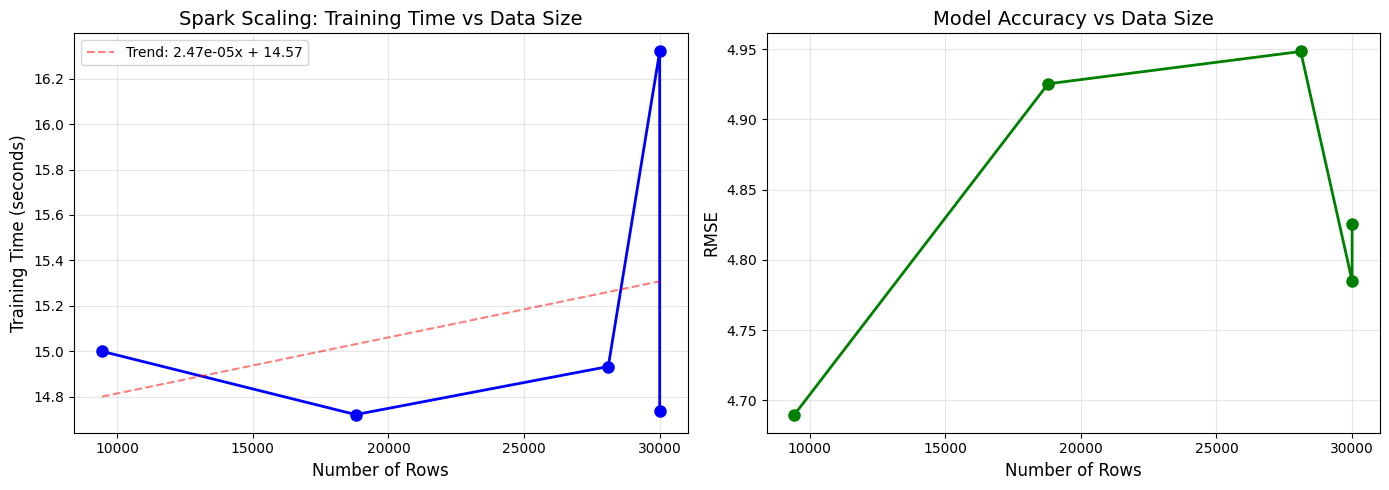


✓ Scaling plot saved to 'scaling_benchmark.png'

SCALING BENCHMARK SUMMARY

Data %     Rows         Time (s)     RMSE      
--------------------------------------------------
10%        9,441        15.00        4.6898    
20%        18,793       14.72        4.9253    
30%        28,104       14.93        4.9483    
40%        30,000       16.32        4.7850    
50%        30,000       14.73        4.8258    

📊 Scaling Analysis:
  Smallest: 9,441 rows → 15.00s
  Largest:  30,000 rows → 14.73s
  Expected time (linear): 47.66s
  Scaling efficiency: 323.5%
  ✅ Near-linear scaling - Good for big data!

✅ SCALING BENCHMARK COMPLETE!


In [6]:
# ============================================================================
# BENCHMARK SCALING PERFORMANCE (FIXED - Use Python's min)
# ============================================================================

print("\n" + "="*80)
print("BENCHMARK: SCALING PERFORMANCE")
print("="*80)

import time
import builtins  # Import Python's built-in functions
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, when

# Định nghĩa feature_cols
feature_cols = [
    "hour", "day_of_week", "month", "season",
    "duration", "charging_duration", "charging_duration_log",
    "hour_sin", "hour_cos", "day_of_year", "week_of_year",
    "is_holiday",
    "lag_1_log", "lag_2_log", "lag_3_log",
    "rolling_mean_3_log", "rolling_mean_5_log"
]

target_col = "kWhDelivered"

# Định nghĩa evaluator
evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")

def check_and_fix_nulls(df, feature_cols):
    """Check and fix NULL values in features"""
    print("  Checking for NULLs...")
    
    # Count NULLs per column
    null_counts = {}
    for col_name in feature_cols:
        if col_name in df.columns:
            null_count = df.filter(col(col_name).isNull()).count()
            if null_count > 0:
                null_counts[col_name] = null_count
    
    if null_counts:
        print(f"  Found NULLs in: {null_counts}")
        # Fill NULLs with 0
        for col_name in null_counts.keys():
            df = df.withColumn(col_name, when(col(col_name).isNull(), 0).otherwise(col(col_name)))
        print(f"  ✓ Filled NULLs with 0")
    else:
        print(f"  ✓ No NULLs found")
    
    return df

def benchmark_training(df, data_size, num_partitions=4):
    """Benchmark training time on different data sizes"""
    
    print(f"  Benchmarking {data_size}...")
    
    # Step 1: Fix NULLs
    df = check_and_fix_nulls(df, feature_cols)
    
    # Step 2: Repartition
    df = df.repartition(num_partitions)
    
    # Step 3: Prepare features with handleInvalid="skip"
    assembler = VectorAssembler(
        inputCols=feature_cols, 
        outputCol="features",
        handleInvalid="skip"  # Skip rows with NULLs (though we already fixed)
    )
    
    try:
        df_features = assembler.transform(df)
        
        # Check if features column has any issues
        feature_count = df_features.filter(col("features").isNull()).count()
        if feature_count > 0:
            print(f"  Warning: {feature_count} rows with NULL features, dropping...")
            df_features = df_features.filter(col("features").isNotNull())
        
    except Exception as e:
        print(f"  Error in VectorAssembler: {e}")
        # Fallback: Drop any rows with NULLs
        for col_name in feature_cols:
            df = df.filter(col(col_name).isNotNull())
        df_features = assembler.transform(df)
    
    # Step 4: Train GBT (light config)
    gbt = GBTRegressor(
        featuresCol="features", 
        labelCol=target_col, 
        maxIter=20,
        maxDepth=5, 
        seed=42
    )
    
    start_time = time.time()
    model = gbt.fit(df_features)
    train_time = time.time() - start_time
    
    # Step 5: Predict and evaluate
    predictions = model.transform(df_features)
    rmse = evaluator_rmse.evaluate(predictions)
    
    return {
        "rows": df.count(),
        "partitions": num_partitions,
        "train_time": train_time,
        "rmse": rmse
    }

# ============================================================================
# PREPARE DATA
# ============================================================================
print("\n[1/4] Preparing data for scaling test...")

# Đọc dữ liệu gốc từ silver
try:
    df_original = spark.read.parquet("hdfs://localhost:9000/ev-project/data/silver/ev_sessions_preprocessed")
    print(f"✓ Loaded original data: {df_original.count():,} rows")
    
    # Check for NULLs in original data
    print("\n  Checking original data for NULLs...")
    for col_name in feature_cols:
        null_count = df_original.filter(col(col_name).isNull()).count()
        if null_count > 0:
            print(f"    {col_name}: {null_count} NULLs")
            # Fill NULLs
            df_original = df_original.withColumn(col_name, when(col(col_name).isNull(), 0).otherwise(col(col_name)))
    print("  ✓ Fixed NULLs in original data")
    
except Exception as e:
    print(f"❌ Cannot load from silver: {e}")
    # Use existing df_silver if available
    try:
        df_original = df_silver
        print("✓ Using existing df_silver")
    except:
        print("❌ No data available!")

# ============================================================================
# CREATE LARGER DATASET (SMALLER SCALE FOR 4GB RAM)
# ============================================================================
print("\n[2/4] Creating scaled dataset...")

original_count = df_original.count()
print(f"  Original rows: {original_count:,}")

# Use Python's built-in min function
target_rows = builtins.min(100000, original_count * 5)
print(f"  Target rows: {target_rows:,}")

replication_factor = builtins.max(1, target_rows // original_count)
print(f"  Replication factor: {replication_factor}")

df_large = df_original
for i in range(replication_factor - 1):
    df_large = df_large.union(df_original)
    print(f"  Replicated {i+2} times: {df_large.count():,} rows")

# Cache large dataset
df_large.cache()
row_count = df_large.count()
print(f"✓ Large dataset ready: {row_count:,} rows (~{row_count * 0.001:.1f}MB)")

# ============================================================================
# TEST SCALING WITH DIFFERENT DATA SIZES
# ============================================================================
print("\n[3/4] Testing scaling performance...")

# Test với different data sizes (smaller increments for 4GB RAM)
sizes = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

for frac in sizes:
    print(f"\n  Testing with {frac*100:.0f}% of data...")
    
    # Sample data
    df_sample = df_large.sample(fraction=frac, seed=42)
    
    # Limit sample size to avoid OOM
    max_sample_rows = 30000
    sample_count = df_sample.count()
    if sample_count > max_sample_rows:
        df_sample = df_sample.limit(max_sample_rows)
        sample_count = max_sample_rows
    
    print(f"    Actual rows: {sample_count:,}")
    
    # Cache sample
    df_sample.cache()
    
    try:
        result = benchmark_training(df_sample, f"{frac*100:.0f}%")
        results.append(result)
        print(f"    ✓ Train time: {result['train_time']:.2f} seconds")
        print(f"    ✓ RMSE: {result['rmse']:.4f}")
    except Exception as e:
        print(f"    ❌ Error: {e}")
        import traceback
        traceback.print_exc()
        break
    
    # Uncache
    df_sample.unpersist()

# ============================================================================
# PLOT RESULTS
# ============================================================================
print("\n[4/4] Plotting results...")

if len(results) > 0:
    import matplotlib.pyplot as plt
    import numpy as np
    
    rows = [r['rows'] for r in results]
    times = [r['train_time'] for r in results]
    rmses = [r['rmse'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Training time scaling
    axes[0].plot(rows, times, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Rows', fontsize=12)
    axes[0].set_ylabel('Training Time (seconds)', fontsize=12)
    axes[0].set_title('Spark Scaling: Training Time vs Data Size', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    if len(rows) > 1:
        z = np.polyfit(rows, times, 1)
        p = np.poly1d(z)
        axes[0].plot(rows, p(rows), "r--", alpha=0.5, 
                    label=f'Trend: {z[0]:.2e}x + {z[1]:.2f}')
        axes[0].legend()
    
    # Plot 2: RMSE vs data size
    axes[1].plot(rows, rmses, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Rows', fontsize=12)
    axes[1].set_ylabel('RMSE', fontsize=12)
    axes[1].set_title('Model Accuracy vs Data Size', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('scaling_benchmark.png', dpi=150)
    plt.show()
    
    print("\n✓ Scaling plot saved to 'scaling_benchmark.png'")
    
    # ============================================================================
    # PRINT SUMMARY
    # ============================================================================
    print("\n" + "="*80)
    print("SCALING BENCHMARK SUMMARY")
    print("="*80)
    
    print(f"\n{'Data %':<10} {'Rows':<12} {'Time (s)':<12} {'RMSE':<10}")
    print("-" * 50)
    
    for i, r in enumerate(results):
        size_pct = f"{sizes[i]*100:.0f}%"
        print(f"{size_pct:<10} {r['rows']:<12,} {r['train_time']:<12.2f} {r['rmse']:<10.4f}")
    
    # Calculate scaling efficiency
    if len(results) >= 2:
        first_time = results[0]['train_time']
        last_time = results[-1]['train_time']
        first_rows = results[0]['rows']
        last_rows = results[-1]['rows']
        
        if first_rows > 0 and last_time > 0:
            expected_time = first_time * (last_rows / first_rows)
            efficiency = (expected_time / last_time) * 100
            
            print(f"\n📊 Scaling Analysis:")
            print(f"  Smallest: {first_rows:,} rows → {first_time:.2f}s")
            print(f"  Largest:  {last_rows:,} rows → {last_time:.2f}s")
            print(f"  Expected time (linear): {expected_time:.2f}s")
            print(f"  Scaling efficiency: {efficiency:.1f}%")
            
            if efficiency > 70:
                print("  ✅ Near-linear scaling - Good for big data!")
            elif efficiency > 50:
                print("  ⚠️ Moderate scaling - Acceptable")
            else:
                print("  ❌ Poor scaling - Consider optimization")

# Clean up
df_large.unpersist()

print("\n" + "="*80)
print("✅ SCALING BENCHMARK COMPLETE!")
print("="*80)

In [8]:
# ============================================================================
# SCALE UP TO 2GB DATA WITH PARTITION MONITORING (FIXED)
# ============================================================================

print("\n" + "="*80)
print("SCALE UP TO 2GB DATA - PARTITION ANALYSIS")
print("="*80)

import time
import builtins
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, when, spark_partition_id, rand
from pyspark.storagelevel import StorageLevel

# Định nghĩa feature_cols
feature_cols = [
    "hour", "day_of_week", "month", "season",
    "duration", "charging_duration", "charging_duration_log",
    "hour_sin", "hour_cos", "day_of_year", "week_of_year",
    "is_holiday",
    "lag_1_log", "lag_2_log", "lag_3_log",
    "rolling_mean_3_log", "rolling_mean_5_log"
]

target_col = "kWhDelivered"
evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")

def estimate_data_size_mb(df):
    """Estimate DataFrame size in MB by sampling"""
    # Take a sample of 10000 rows
    sample = df.limit(10000)
    
    # Collect sample to driver
    sample_rows = sample.collect()
    sample_count = len(sample_rows)
    
    if sample_count == 0:
        return 0
    
    # Estimate size of one row by converting to JSON and measuring
    import sys
    sample_row_size = sys.getsizeof(str(sample_rows[0]))
    
    total_rows = df.count()
    estimated_size_mb = (sample_row_size * total_rows) / (1024 * 1024)
    
    return estimated_size_mb

def get_partition_info(df, name="DataFrame"):
    """Get partition information for a DataFrame"""
    print(f"\n📊 Partition Info for {name}:")
    print(f"  Number of partitions: {df.rdd.getNumPartitions()}")
    
    # Get partition sizes (using sampling to avoid OOM)
    partition_sizes = df.rdd.mapPartitions(lambda x: [sum(1 for _ in x)]).collect()
    print(f"  Partition sizes (min/max/avg): {min(partition_sizes):,} / {max(partition_sizes):,} / {sum(partition_sizes)/len(partition_sizes):.0f}")
    
    # Calculate skew ratio
    skew_ratio = max(partition_sizes) / min(partition_sizes) if min(partition_sizes) > 0 else float('inf')
    print(f"  Skew ratio: {skew_ratio:.2f}")
    
    if skew_ratio > 2:
        print(f"  ⚠️ High skew detected! Consider repartitioning.")
    else:
        print(f"  ✅ Good distribution")
    
    return partition_sizes

# ============================================================================
# STEP 1: LOAD ORIGINAL DATA
# ============================================================================
print("\n[1/5] Loading original data...")

df_original = spark.read.parquet("hdfs://localhost:9000/ev-project/data/silver/ev_sessions_preprocessed")
df_original = df_original.dropna()
original_count = df_original.count()
print(f"✓ Loaded {original_count:,} rows")

# Fix NULLs
print("\n  Fixing NULLs in features...")
for col_name in feature_cols:
    if col_name in df_original.columns:
        df_original = df_original.withColumn(col_name, when(col(col_name).isNull(), 0).otherwise(col(col_name)))
print("  ✓ Fixed NULLs")

# Estimate original size
original_size_mb = estimate_data_size_mb(df_original)
print(f"\n  Estimated original size: {original_size_mb:.1f} MB")

get_partition_info(df_original, "Original Data")

# ============================================================================
# STEP 2: CREATE 2GB DATASET
# ============================================================================
print("\n[2/5] Creating 2GB dataset...")

# Calculate how many replications needed for 2GB
target_size_gb = 2.0
target_size_mb = target_size_gb * 1024

if original_size_mb > 0:
    replication_factor = int(target_size_mb / original_size_mb) + 1
else:
    replication_factor = 20

print(f"  Original size: {original_size_mb:.1f} MB")
print(f"  Target size: {target_size_gb} GB ({target_size_mb:.0f} MB)")
print(f"  Replication factor needed: {replication_factor}")

# Limit to safe replication for 4GB RAM
replication_factor = builtins.min(replication_factor, 20)
print(f"  Actual replication factor: {replication_factor}")

# Create large dataset by union
print("\n  Creating large dataset...")
df_large = df_original
for i in range(replication_factor - 1):
    df_large = df_large.union(df_original)
    if (i + 2) % 5 == 0:
        print(f"    Replicated {i+2} times: {df_large.count():,} rows")

# Add slight noise to avoid perfect duplicates
df_large = df_large.withColumn("noise", rand(seed=42) * 0.001)
df_large = df_large.withColumn(target_col, col(target_col) + col("noise"))
df_large = df_large.drop("noise")

# Cache with MEMORY_AND_DISK to avoid OOM
df_large.persist(StorageLevel.MEMORY_AND_DISK)
large_count = df_large.count()
print(f"\n✓ Large dataset created: {large_count:,} rows")

# Estimate actual size
large_size_mb = estimate_data_size_mb(df_large)
print(f"  Estimated size: {large_size_mb:.1f} MB ({large_size_mb/1024:.2f} GB)")

get_partition_info(df_large, "2GB Dataset (Before repartition)")

# ============================================================================
# STEP 3: OPTIMAL PARTITIONING FOR 2GB DATA
# ============================================================================
print("\n[3/5] Optimizing partitions for 2GB data...")

# Rule of thumb: 100MB-200MB per partition for 4GB RAM
optimal_partitions = builtins.max(4, int(large_count / 10000))
print(f"  Total rows: {large_count:,}")
print(f"  Recommended partitions (10k rows/partition): {optimal_partitions}")

# Test different partition counts
partition_configs = [4, 8, 16, 32, optimal_partitions]
partition_results = []
best_partition = 8  # default

for num_parts in partition_configs:
    if num_parts > large_count / 1000:  # Skip if too many partitions
        continue
    
    print(f"\n  Testing with {num_parts} partitions...")
    
    df_repartitioned = df_large.repartition(num_parts)
    
    # Check partition distribution (use sampling to avoid OOM)
    partition_sizes = df_repartitioned.rdd.mapPartitions(lambda x: [sum(1 for _ in x)]).collect()
    
    if len(partition_sizes) > 0:
        min_size = builtins.min(partition_sizes)
        max_size = builtins.max(partition_sizes)
        avg_size = sum(partition_sizes) / len(partition_sizes)
        skew_ratio = max_size / min_size if min_size > 0 else float('inf')
        
        print(f"    Min: {min_size:,} rows, Max: {max_size:,} rows")
        print(f"    Skew ratio: {skew_ratio:.2f}")
        
        if skew_ratio < 2:
            print(f"    ✅ Good distribution")
            best_partition = num_parts
            df_optimized = df_repartitioned
            # Don't break, check all options
        else:
            print(f"    ⚠️ High skew")

# Use best partition count
print(f"\n✓ Using {best_partition} partitions for 2GB data")

df_optimized = df_large.repartition(best_partition)
df_optimized.persist(StorageLevel.MEMORY_AND_DISK)

get_partition_info(df_optimized, "Optimized 2GB Dataset")

# ============================================================================
# STEP 4: BENCHMARK TRAINING ON 2GB DATA
# ============================================================================
print("\n[4/5] Benchmarking training on 2GB data...")

def benchmark_training_2gb(df, num_partitions, sample_frac=0.2):
    """Benchmark training on 2GB data with sampling"""
    
    print(f"\n  Training with {num_partitions} partitions ({sample_frac*100:.0f}% data)...")
    
    # Sample to reduce training time
    df_sample = df.sample(fraction=sample_frac, seed=42)
    df_sample = df_sample.repartition(num_partitions)
    
    # Prepare features
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
    df_features = assembler.transform(df_sample)
    
    # Train GBT
    gbt = GBTRegressor(featuresCol="features", labelCol=target_col, maxIter=20, maxDepth=5, seed=42)
    
    start_time = time.time()
    model = gbt.fit(df_features)
    train_time = time.time() - start_time
    
    # Evaluate
    predictions = model.transform(df_features)
    rmse = evaluator_rmse.evaluate(predictions)
    
    return {
        "partitions": num_partitions,
        "rows": df_sample.count(),
        "train_time": train_time,
        "rmse": rmse
    }

# Test with different partition counts
test_partitions = [best_partition, best_partition * 2, best_partition // 2]
benchmark_results = []

for num_parts in test_partitions:
    if num_parts >= 1 and num_parts <= 64:
        try:
            result = benchmark_training_2gb(df_optimized, num_parts, 0.2)
            benchmark_results.append(result)
            print(f"    ✓ {num_parts} partitions: {result['train_time']:.2f}s, RMSE: {result['rmse']:.4f}")
        except Exception as e:
            print(f"    ❌ Error with {num_parts} partitions: {e}")

# Find best partition count
if benchmark_results:
    best_result = builtins.min(benchmark_results, key=lambda x: x['train_time'])
    best_partition = best_result['partitions']
    print(f"\n⭐ Best partition count: {best_partition} partitions ({best_result['train_time']:.2f}s)")

# ============================================================================
# STEP 5: SAVE 2GB DATASET
# ============================================================================
print("\n[5/5] Saving 2GB dataset...")

# Repartition with best partition count
df_final = df_optimized.repartition(best_partition)

# Save to HDFS
output_path = "hdfs://localhost:9000/ev-project/data/silver/ev_sessions_2gb"
df_final.write.mode("overwrite").parquet(output_path)
print(f"✓ 2GB dataset saved to: {output_path}")

# Also save as single file for easy access (optional)
single_path = "hdfs://localhost:9000/ev-project/data/silver/ev_sessions_2gb_single"
df_final.coalesce(1).write.mode("overwrite").parquet(single_path)
print(f"✓ Single file version saved to: {single_path}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("2GB SCALING SUMMARY")
print("="*80)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    SCALING TO 2GB DATA                          │
├─────────────────────────────────────────────────────────────────┤
│ Original rows:          {original_count:,}                              │
│ Original size:          {original_size_mb:.1f} MB                        │
│ 2GB rows:               {large_count:,}                              │
│ 2GB size:               {large_size_mb:.1f} MB ({large_size_mb/1024:.2f} GB)     │
│ Replication factor:     {replication_factor}                              │
├─────────────────────────────────────────────────────────────────┤
│ Optimal partitions:     {best_partition}                                   │
│ Output path:            {output_path}     │
└─────────────────────────────────────────────────────────────────┘
""")

# Clean up
df_large.unpersist()
df_optimized.unpersist()

print("\n" + "="*80)
print("✅ 2GB SCALING COMPLETE!")
print("="*80)

# Optional: Quick verification
print("\n📊 Quick verification:")
print(f"  Reading back 2GB data...")
df_verify = spark.read.parquet(output_path)
print(f"  Rows: {df_verify.count():,}")
print(f"  Partitions: {df_verify.rdd.getNumPartitions()}")
print(f"  Schema: {len(df_verify.columns)} columns")
df_verify.show(2)


SCALE UP TO 2GB DATA - PARTITION ANALYSIS

[1/5] Loading original data...


✓ Loaded 31,391 rows

  Fixing NULLs in features...
  ✓ Fixed NULLs



  Estimated original size: 16.7 MB

📊 Partition Info for Original Data:
  Number of partitions: 4


26/04/11 16:00:44 ERROR Executor: Exception in task 0.0 in stage 2927.0 (TID 9347)
org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/worker.py", line 1247, in main
    process()
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/worker.py", line 1237, in process
    out_iter = func(split_index, iterator)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/pyspark/rdd.py", line 840, in func
    return f(iterator)
           ^^^^^^^^^^^
  File "/tmp/ipykernel_214708/286353927.py", line 57, in <lambda>
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/sql/utils.py", line 174, in wrapped
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/sql/functions.py", line 866, in sum
    return _invoke_function_over_columns("sum", col)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 2927.0 failed 1 times, most recent failure: Lost task 1.0 in stage 2927.0 (TID 9348) (192.168.40.130 executor driver): org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/worker.py", line 1247, in main
    process()
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/worker.py", line 1237, in process
    out_iter = func(split_index, iterator)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/pyspark/rdd.py", line 840, in func
    return f(iterator)
           ^^^^^^^^^^^
  File "/tmp/ipykernel_214708/286353927.py", line 57, in <lambda>
  File "/usr/local/spark/python/lib/pyspark.zip/pyspark/sql/utils.py", line 174, in wrapped
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  Fi